# GeomechPy — Basic Calculations

This notebook walks through the core building blocks of **GeomechPy**, one calculation at a time:

1. [Elastic properties](#1.-Elastic-properties) — converting between moduli and computing dynamic moduli from sonic measurements
2. [Dynamic → static calibration and rock strength](#2.-Dynamic-→-static-calibration-and-rock-strength)
3. [Pore pressure and overburden stress](#3.-Pore-pressure-and-overburden-stress)
4. [Horizontal stresses](#4.-Horizontal-stresses)
5. [Wellbore stability — vertical and deviated wells](#5.-Wellbore-stability)
6. [Working with units](#6.-Working-with-units)

Every calculation exists in a **single-value** form and an **`_array`** form (plain `list[float]` in, list out) for depth-indexed log data. Results with several components come back as **frozen dataclasses**, and every docstring states its units and literature reference.

> Install: `pip install .` from the repository root (`pip install .[pandas,plotting]` for the optional extras).

In [1]:
from geomechpy import (
    DynamicElasticPropertiesCalculation,
    ElasticPropertiesConverter,
    FractureGradientCalculation,
    HorizontalStressesCalculation,
    OverburdenStressCalculation,
    PorePressureCalculation,
    RockStrengthPropertiesConverter,
    StaticElasticPropertiesConverter,
    UnitConverter,
    WellboreStabilityCalculation,
)

## 1. Elastic properties

### From any pair of moduli

For an isotropic rock, **any two** elastic moduli define all the others. `ElasticPropertiesConverter` implements all 15 pairwise conversions between bulk modulus $K$, Young's modulus $E$, Lamé parameter $\lambda$, shear modulus $G$, Poisson's ratio $\nu$ and P-wave modulus $M$. The conversions are *unit-agnostic*: use any consistent pressure unit and the results come back in that unit.

In [2]:
# A sandstone with E = 25 GPa and Poisson's ratio 0.22 — get everything else
props = ElasticPropertiesConverter.convert_from_youngs_and_poissons(youngs_modulus=25.0, poissons_ratio=0.22)
print(f"Bulk modulus:    {props.bulk_modulus:6.2f} GPa")
print(f"Shear modulus:   {props.shear_modulus:6.2f} GPa")
print(f"Lame parameter:  {props.lame_parameter:6.2f} GPa")
print(f"P-wave modulus:  {props.p_wave_modulus:6.2f} GPa")

Bulk modulus:     14.88 GPa
Shear modulus:    10.25 GPa
Lame parameter:    8.05 GPa
P-wave modulus:   28.54 GPa


### Dynamic moduli from sonic measurements

At the wellsite we measure **velocities** (or their inverse, **slownesses** from the sonic log) plus bulk density. The physics is simply $G = \rho V_s^2$ and $M = \rho V_p^2$, after which the pairwise conversions give the full set. `DynamicElasticPropertiesCalculation` wraps this and also reports the Vp/Vs ratio (a lithology/fluid indicator). Unit arguments let you choose the input and output units.

In [3]:
# From velocities (m/s) and density (kg/m3), moduli reported in GPa
from_velocity = DynamicElasticPropertiesCalculation.calculate_from_velocity(
    p_wave_velocity=4000.0, s_wave_velocity=2400.0, density=2650.0, modulus_unit="GPa"
)
print(f"E dynamic = {from_velocity.youngs_modulus:.1f} GPa, PR = {from_velocity.poissons_ratio:.3f}, Vp/Vs = {from_velocity.vp_vs_ratio:.2f}")

# The same point from sonic log slownesses (us/ft) — DTCO / DTSH
from_slowness = DynamicElasticPropertiesCalculation.calculate_from_slowness(
    p_wave_slowness=76.2, s_wave_slowness=127.0, density=2650.0, modulus_unit="GPa"
)
print(f"E dynamic = {from_slowness.youngs_modulus:.1f} GPa, PR = {from_slowness.poissons_ratio:.3f}, Vp/Vs = {from_slowness.vp_vs_ratio:.2f}")

E dynamic = 37.2 GPa, PR = 0.219, Vp/Vs = 1.67
E dynamic = 37.2 GPa, PR = 0.219, Vp/Vs = 1.67


In [4]:
# Array (log-style) usage: one entry per depth sample
dtco = [76.2, 80.0, 85.3]        # us/ft
dtsh = [127.0, 135.5, 142.1]     # us/ft
rhob = [2650.0, 2600.0, 2550.0]  # kg/m3

log = DynamicElasticPropertiesCalculation.calculate_from_slowness_array(dtco, dtsh, rhob, modulus_unit="GPa")
for sample, entry in enumerate(log):
    print(f"sample {sample}: E = {entry.youngs_modulus:5.1f} GPa   PR = {entry.poissons_ratio:.3f}")

sample 0: E =  37.2 GPa   PR = 0.219
sample 1: E =  32.4 GPa   PR = 0.232
sample 2: E =  28.6 GPa   PR = 0.218


## 2. Dynamic → static calibration and rock strength

Log-derived (dynamic) moduli are measured at tiny strains and high frequency; laboratory (static) moduli — the ones used in stress and stability calculations — are systematically **lower**. GeomechPy ships several published calibrations (Bradford, Najibi, Fuller, Morales) plus custom power/linear laws for your own core regressions.

Rock strength is then estimated from the calibrated static properties:
- **UCS** from static Young's modulus (Plumb generic: UCS[MPa] = 1.45·E[GPa])
- **Tensile strength** as a fraction of UCS (default 0.15)
- **Friction angle** from compressional slowness (Lal, shale)

In [5]:
yme_dyn_mpsi = UnitConverter.convert_pressure(from_slowness.youngs_modulus, "GPa", "Mpsi")

# Najibi et al. (2015) calibration for carbonates — try Bradford/Fuller/Morales for other lithologies
yme_sta_mpsi = StaticElasticPropertiesConverter.dyn2sta_yme_najib(yme_dyn=yme_dyn_mpsi)
print(f"E dynamic = {yme_dyn_mpsi:.2f} Mpsi  ->  E static = {yme_sta_mpsi:.2f} Mpsi")

ucs = RockStrengthPropertiesConverter.convert_yme_sta_to_ucs_plumb(yme_sta=yme_sta_mpsi)
tstr = RockStrengthPropertiesConverter.convert_ucs_to_tstr(ucs=ucs)
fang = RockStrengthPropertiesConverter.convert_friction_angle_lal(dtco=76.2)
print(f"UCS = {ucs:.0f} psi, tensile strength = {tstr:.0f} psi, friction angle = {fang:.1f} deg")

E dynamic = 5.40 Mpsi  ->  E static = 1.98 Mpsi
UCS = 2872 psi, tensile strength = 431 psi, friction angle = 36.9 deg


## 3. Pore pressure and overburden stress

The gradient-based methods handle the **air gap** (Kelly bushing elevation) and, offshore, the **sea water column**. Gradients can be given in any `<pressure>/<depth>` combination or directly as an **equivalent mud weight** (ppg, SG) via `gradient_unit` — the units the field actually quotes them in.

In [6]:
tvd = 10000.0  # ft

# Pore pressure with the gradient quoted as 9.0 ppg equivalent mud weight
pp = PorePressureCalculation.calculate_pore_pressure_onshore(
    tvd=tvd, formation_pore_pressure_gradient=9.0, gradient_unit="ppg"
)

# Overburden from a 1.0 psi/ft lithostatic gradient
sv = OverburdenStressCalculation.calculate_overburden_stress_onshore(tvd=tvd, lithostatic_gradient=1.0)

print(f"Pore pressure at {tvd:.0f} ft: {pp:.0f} psi ({UnitConverter.convert_pressure_to_mud_weight(pp, tvd):.2f} ppg EMW)")
print(f"Overburden at {tvd:.0f} ft:    {sv:.0f} psi")

Pore pressure at 10000 ft: 4675 psi (9.00 ppg EMW)
Overburden at 10000 ft:    10000 psi


In [7]:
# More realistic: integrate an actual density profile instead of a constant gradient.
# Density increases with compaction; the integration honors every sample.
tvd_profile = [8000.0, 8500.0, 9000.0, 9500.0, 10000.0]      # ft
rhob_profile = [2450.0, 2500.0, 2540.0, 2575.0, 2600.0]      # kg/m3

sv_profile = OverburdenStressCalculation.calculate_overburden_stress_from_density_array(
    tvd=tvd_profile, density=rhob_profile
)
for depth, stress in zip(tvd_profile, sv_profile):
    print(f"TVD {depth:7.0f} ft : Sv = {stress:7.0f} psi ({stress/depth:.3f} psi/ft average)")

TVD    8000 ft : Sv =    8497 psi (1.062 psi/ft average)
TVD    8500 ft : Sv =    9034 psi (1.063 psi/ft average)
TVD    9000 ft : Sv =    9580 psi (1.064 psi/ft average)
TVD    9500 ft : Sv =   10134 psi (1.067 psi/ft average)
TVD   10000 ft : Sv =   10695 psi (1.070 psi/ft average)


## 4. Horizontal stresses

Three approaches, in increasing order of input requirements:

| Method | Equation | When to use |
|---|---|---|
| **Eaton (uniaxial strain)** | $S_{hmin} = \frac{\nu}{1-\nu}(S_v - \alpha P_p) + \alpha P_p$ | Quick estimate from Poisson's ratio |
| **Calibrated $K_0$** | $S_{hmin} = K_0(S_v - P_p) + P_p$ | You have LOT / minifrac closure data |
| **Poroelastic (Thiercelin & Plumb)** | adds $\frac{E}{1-\nu^2}(\varepsilon_x + \nu\varepsilon_y)$ | Tectonically strained basins, gives SHmax too |

In [8]:
pr_sta = 0.25

shmin_eaton = HorizontalStressesCalculation.calculate_shmin_eaton(sv, pp, poisson_ratio=pr_sta)
shmin_k0 = HorizontalStressesCalculation.calculate_shmin_effective_stress_ratio(sv, pp, effective_stress_ratio=0.75)
poroelastic = HorizontalStressesCalculation.calculate_poroelastic_horizontal_stresses(
    overburden_stress=sv, pore_pressure=pp, poisson_ratio=pr_sta, youngs_modulus=yme_sta_mpsi,
    EX=0.0001, EY=0.0004,  # small anisotropic tectonic strains
)

print(f"Shmin (Eaton, PR=0.25):      {shmin_eaton:7.0f} psi")
print(f"Shmin (K0 = 0.75 from LOT):  {shmin_k0:7.0f} psi")
print(f"Shmin (poroelastic):         {poroelastic.shmin:7.0f} psi")
print(f"SHmax (poroelastic):         {poroelastic.shmax:7.0f} psi")
print(f"Stress regime q-factor:      {poroelastic.q_factor:7.2f}  (0-1 normal, 1-2 strike-slip, 2-3 reverse)")

Shmin (Eaton, PR=0.25):         6450 psi
Shmin (K0 = 0.75 from LOT):     8669 psi
Shmin (poroelastic):            6873 psi
SHmax (poroelastic):            7348 psi
Stress regime q-factor:         2.94  (0-1 normal, 1-2 strike-slip, 2-3 reverse)


## 5. Wellbore stability

For a **vertical well** the Mohr-Coulomb breakout pressure and the tensile breakdown pressure have analytical solutions. For **deviated/inclined wells** GeomechPy rotates the full stress tensor into the borehole frame, evaluates the Kirsch effective stresses around the wall and finds the limits numerically — at zero deviation the numerical solutions reproduce the analytical ones.

The `MudWeightWindow` bundles the four operational limits; the safe static mud pressure sits between `max(kick, breakout)` and `min(loss, breakdown)`.

In [9]:
stability_inputs = dict(
    shmax=poroelastic.shmax, shmin=poroelastic.shmin, pprs=pp, overburden_stress=sv,
    ucs=ucs, fang=fang, pr_sta=pr_sta, tstr=tstr,
)

vertical = WellboreStabilityCalculation.calculate_mud_weight_window_vertical_well(**stability_inputs)
deviated = WellboreStabilityCalculation.calculate_mud_weight_window_deviated_well(
    **stability_inputs, borehole_deviation=60.0, borehole_azimuth=90.0,
)

def describe(window, label):
    lower = max(window.kick_pressure, window.breakout_pressure)
    upper = min(window.loss_pressure, window.breakdown_pressure)
    lo_ppg = UnitConverter.convert_pressure_to_mud_weight(lower, tvd)
    hi_ppg = UnitConverter.convert_pressure_to_mud_weight(upper, tvd)
    print(f"{label:22s} kick {window.kick_pressure:6.0f} | breakout {window.breakout_pressure:6.0f} | "
          f"loss {window.loss_pressure:6.0f} | breakdown {window.breakdown_pressure:6.0f} psi"
          f"   ->  safe EMW {lo_ppg:.2f} - {hi_ppg:.2f} ppg")

describe(vertical, "Vertical well:")
describe(deviated, "60 deg deviated well:")

Vertical well:         kick   4675 | breakout   5348 | loss   6873 | breakdown   9026 psi   ->  safe EMW 10.29 - 13.23 ppg
60 deg deviated well:  kick   4675 | breakout   6523 | loss   6873 | breakdown   8582 psi   ->  safe EMW 12.56 - 13.23 ppg


The deviated well needs **heavier mud** to stay in gauge — the classic result in a normal-faulting stress regime.

The stress polygon shows where this stress state sits relative to the frictional-equilibrium limits (requires the `plotting` extra):

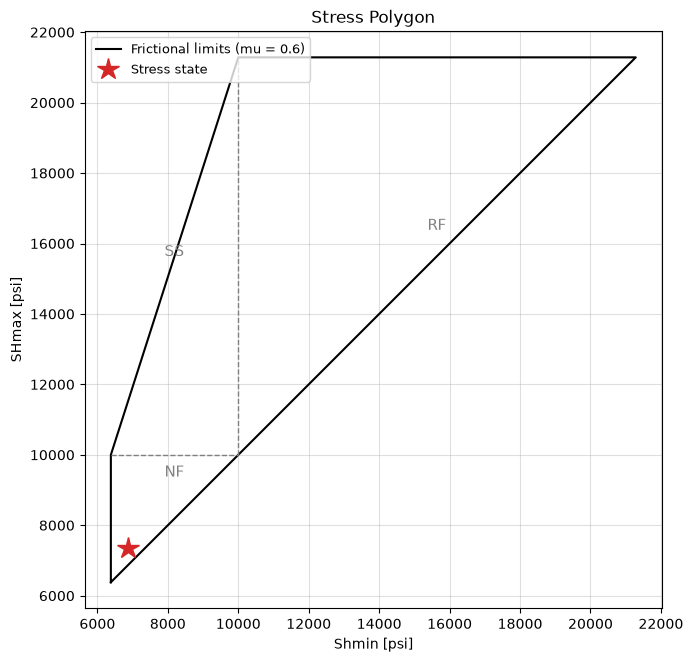

In [10]:
from geomechpy import plot_stress_polygon

figure = plot_stress_polygon(
    shmin=poroelastic.shmin, shmax=poroelastic.shmax,
    overburden_stress=sv, pore_pressure=pp,
)

## 6. Working with units

`UnitConverter` moves any quantity between unit systems — including drilling-specific ones like equivalent mud weight — and the unit-bound calculations accept the same unit names directly.

In [11]:
# Pressure, gradients, mud weights
print(f"5000 psi                 = {UnitConverter.convert_pressure(5000, 'psi', 'MPa'):.2f} MPa")
print(f"0.47 psi/ft              = {UnitConverter.convert_pressure_gradient(0.47, 'psi/ft', 'kPa/m'):.2f} kPa/m")
print(f"1.20 SG mud              = {UnitConverter.convert_density(1.20, 'SG', 'ppg'):.2f} ppg")
print(f"12 ppg at 3000 m         = {UnitConverter.convert_mud_weight_to_pressure(12.0, 3000.0, 'ppg', 'MPa', 'm'):.1f} MPa downhole")

# The same calculation in field and metric units agrees exactly
pp_field = PorePressureCalculation.calculate_pore_pressure_onshore(tvd=10000.0)                        # ft -> psi
pp_metric = PorePressureCalculation.calculate_pore_pressure_onshore(tvd=3048.0, depth_unit="m", pressure_unit="kPa")
print(f"\nField: {pp_field:.1f} psi   Metric: {pp_metric:.0f} kPa = {UnitConverter.convert_pressure(pp_metric, 'kPa', 'psi'):.1f} psi")

5000 psi                 = 34.47 MPa
0.47 psi/ft              = 10.63 kPa/m
1.20 SG mud              = 10.01 ppg
12 ppg at 3000 m         = 42.3 MPa downhole

Field: 4700.0 psi   Metric: 32405 kPa = 4700.0 psi


## Where to go next

- **`02_full_mem_workflow.ipynb`** builds a complete 1D Mechanical Earth Model from synthetic well logs, with the multi-track profile and mud weight window plots.
- **`skills.md`** in the repository root lists every capability, and each method's docstring documents its units and literature reference.